### Fig. 4: Subpolar North Atlantic heat content and accumulated throughput anomaly

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import os
import dask.config  
import gsw
import warnings
warnings.filterwarnings("ignore") 

dir_GO8p7 = 'YOUR_MODEL_DATA_PATH' #directory for GO8p7-eORCA12 data
dir_GO8p7_grid = 'YOUR_GRID_PATH'  #directory for GO8p7-eORCA12 grid files

#os.environ["OMP_NUM_THREADS"] = "8"

In [2]:
# Grid GO8p7-eORCA12
ds_grid_go8p7 = xr.open_dataset(dir_GO8p7_grid + 'mesh_hgr_NH.nc')
#display(ds_grid_go8p7)

lont = ds_grid_go8p7['glamt'].squeeze(dim='t')  #longitude t-grid
latt = ds_grid_go8p7['gphit'].squeeze(dim='t')  #latitude t-grid

dxt = ds_grid_go8p7['e1t'].squeeze(dim='t')
dyt = ds_grid_go8p7['e2t'].squeeze(dim='t')
lev = ds_grid_go8p7['nav_lev']

ds_grid_go8p7.close()

# 0-1000m
lev_1000 = 45
print(lev[lev_1000].values)

(1565, 4322)
947.4479


In [4]:
# Pressure levels from depth levels
pres=gsw.conversions.p_from_z(-lev, latt, geo_strf_dyn_height=0, sea_surface_geopotential=0)
pres_1000 = pres[0:lev_1000+1:,:]
print(pres_1000.shape)

(46, 1565, 4322)


In [5]:
# Read in fields to compute heat content (1990-2021)
data_path = dir_GO8p7 + 'dap.ceda.ac.uk/bodc/SOC220065/GO8p7_JRA55_eORCA12/monthly/T/'
files = [os.path.join(data_path, f) for f in os.listdir(data_path) if f.startswith('nemo_g8p7ho_1m_') and f.endswith('_grid-T.nc')]
files = sorted(files)
files = files[132:]  #limit to 1990-2021

Nt=len(files)
Nx=len(latt[:,1])
Ny=len(latt[1,:])
             
hc_mon = np.zeros((Nt,Nx,Ny))
f=0
heatcap = 3991.8679571196 #J/kg C

with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    for file in files: #loop over model data-paths
        print(f)
        
        ds = xr.open_mfdataset(file)
        #display(ds)
        
        temp  = ds.thetao_con.isel(deptht=slice(0,lev_1000+1)).squeeze(dim='time_counter').values #conservative teperature
        sal  = ds.so_abs.isel(deptht=slice(0,lev_1000+1)).squeeze(dim='time_counter').values      #absolute salinity
        dz_var = ds.thkcello.isel(deptht=slice(0,lev_1000+1)).squeeze(dim='time_counter').values  #time-varying dz

        rho = gsw.rho(sal, temp, pres_1000) #in-situ density
        del sal
        
        hc_mon[f,:,:] = np.nansum(temp * rho * dz_var, axis=0) * dxt.values * dyt.values * heatcap #sum in depth 0-1000m layer

        f=f+1
        ds.close()
        del temp, dz_var, rho
        

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [6]:
# Annual means
tt=0 #count
y=32 #number of years (1990-2021)
Nt = 12*y
hc_an = np.zeros((y,Nx,Ny))

for m in range(0,Nt,12):
    hc_an[tt,:,:] =np.mean(hc_mon[m:m+12,:,:], axis=0)
    tt=tt+1

del hc_mon

(32, 1565, 4322)


In [7]:
# Throughput time series (1990-2017)

# Upload saved data (saved in part_quant_1990-2017.py)
dir_quant='YOUR_DATA_PATH' #directory for vtSPG_an_1990-2017_data.csv
df_spg = pd.read_csv(dir_quant+'vtSPG_an_1990-2017_data.csv') #read the CSV file 

VTspg = df_spg.vtSPG.values/1e+6/12 #annual mean VT in Sverdrup
yrs=df_spg.year.values

In [16]:
# SPNA heat content 
geo_mask = (latt.values >= 45) & (latt.values <= 65) & (lont.values >= -80) & (lont.values <= 10)

hc_spna = np.zeros(y)

for m in range(0,y):
    hc = hc_an[m,:,:]
    hc[~geo_mask] = 0 #set values outside SPNA mask to zero
    hc_spna[m] = np.nansum(hc,axis=(0,1)) #integrate over SPNA area
    
yrs_hc = range(1990,2021+1,1)

(1565, 4322)
[1.70341577e+23 1.70715880e+23 1.71760775e+23 1.70379971e+23
 1.68652505e+23 1.70250611e+23 1.76111495e+23 1.77374505e+23
 1.78712066e+23 1.77289515e+23 1.76304634e+23 1.75967410e+23
 1.75145022e+23 1.75543502e+23 1.78152985e+23 1.79035527e+23
 1.79414961e+23 1.76310556e+23 1.74154583e+23 1.72537346e+23
 1.70864758e+23 1.71431650e+23 1.70963478e+23 1.71482510e+23
 1.66035466e+23 1.62574989e+23 1.62113439e+23 1.65335429e+23
 1.65993017e+23 1.66587019e+23 1.64469456e+23 1.66947382e+23]
range(1990, 2022)


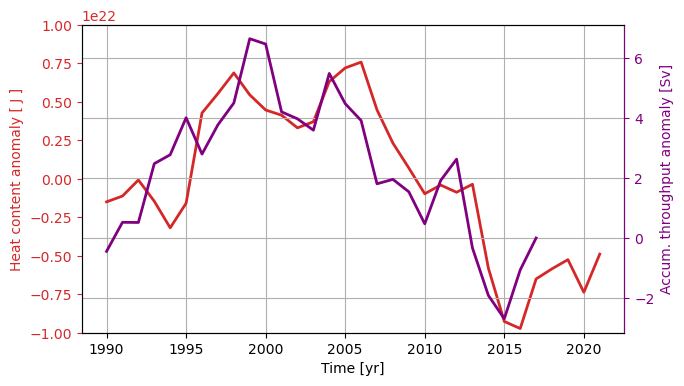

In [15]:
# Plotting Fig. 4

# Anomalies relative to the time period mean
hc_spna_anom = hc_spna - np.mean(hc_spna)
VTspg_anom = VTspg - np.mean(VTspg)

fig, ax1 = plt.subplots(1, 1, figsize=(7, 4))
ax1.plot(yrs_hc,hc_spna_anom,color='C3',linewidth=2,label='..')
ax1.grid(axis='x')
ax1.set_xlabel('Time [yr]')
ax1.tick_params(axis='y', labelcolor='C3', colors='C3')
ax1.spines['left'].set_color('C3')
ax1.set_ylabel('Heat content anomaly [ J ]', color='C3')
ax1.set_ylim(-1e+22,1e+22)
#
ax2 = ax1.twinx()
ax2.patch.set_visible(False)  
#
ax2.plot(yrs,np.cumsum(VTspg_anom),color='Purple',linewidth=2,label='Throughput') 
ax2.grid(axis='y') 
ax2.tick_params(axis='y', labelcolor='Purple', colors='Purple')
ax2.spines['right'].set_color('Purple')
ax2.set_ylabel('Accum. throughput anomaly [Sv]', color='Purple')
#
ax1.spines['left'].set_color('C0')